In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

In [2]:
mode = 'BandRemoval:2'
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
print(path)

D:/DeepSSFP/block_phantom_bandremoval_2


Generating phantom...
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:64: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:91: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (100, 128, 128, 4)


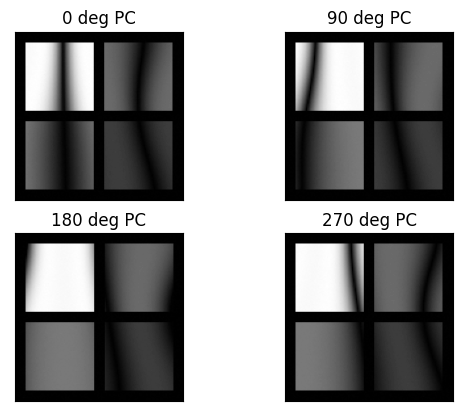

(80, 128, 128, 4) (80, 128, 128, 2)


In [3]:
dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=100, shape=128, npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], useRotate=True, useDeform=True)
data = dataset['M']
data.shape
mssfp.plot_dataset(data, slice=0)
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)

plt.figure()
plt.subplot(1,1,1)
plt.imshow(np.abs(ds.x_train[0,:,:,0] + 1j * ds.x_train[0,:,:,1]))
plt.subplot(1,1,1)
plt.imshow(np.abs(ds.y_train[0,:,:,0] + 1j * ds.y_train[0,:,:,1]))
plt.show()

In [4]:
# Basic training
model, history, ds, predictions = deepssfp.train(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir,
    custom_dataset=ds,
    epochs=400,
    use_early_stopping=False,
    patience=200,
    continue_training=False
)

2025-03-19 11:22:31,065 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_bandremoval_2
2025-03-19 11:22:31,066 - DeepSSFP - INFO - Training DataSet: (80, 128, 128, 4) | (80, 128, 128, 2)
2025-03-19 11:22:31,066 - DeepSSFP - INFO - Test DataSet: (20, 128, 128, 4) | (20, 128, 128, 2)
2025-03-19 11:22:31,617 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x4→2


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 4) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-19 11:22:38,842 - tensorflow - WARNING - Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0248s vs `on_train_batch_end` time: 0.1704s). Check your callbacks.


20/20 - 9s - loss: 0.2547 - mean_absolute_error: 0.2986 - val_loss: 0.1969 - val_mean_absolute_error: 0.2921

Epoch 00001: val_loss improved from inf to 0.19693, saving model to D:/DeepSSFP\block_phantom_bandremoval_2.keras
Epoch 2/400
20/20 - 1s - loss: 0.0209 - mean_absolute_error: 0.0980 - val_loss: 0.0596 - val_mean_absolute_error: 0.1611

Epoch 00002: val_loss improved from 0.19693 to 0.05964, saving model to D:/DeepSSFP\block_phantom_bandremoval_2.keras
Epoch 3/400
20/20 - 1s - loss: 0.0102 - mean_absolute_error: 0.0669 - val_loss: 0.0186 - val_mean_absolute_error: 0.0903

Epoch 00003: val_loss improved from 0.05964 to 0.01855, saving model to D:/DeepSSFP\block_phantom_bandremoval_2.keras
Epoch 4/400
20/20 - 1s - loss: 0.0074 - mean_absolute_error: 0.0573 - val_loss: 0.0091 - val_mean_absolute_error: 0.0620

Epoch 00004: val_loss improved from 0.01855 to 0.00912, saving model to D:/DeepSSFP\block_phantom_bandremoval_2.keras
Epoch 5/400
20/20 - 1s - loss: 0.0058 - mean_absolute_er

2025-03-19 11:36:04,170 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_bandremoval_2.keras


1/1 [==============================] - 1s 1s/step - loss: 1.5536e-04 - mean_absolute_error: 0.0088


2025-03-19 11:36:05,629 - DeepSSFP - INFO - Training Complete. Loss: 0.0002, MAE: 0.0088
2025-03-19 11:36:05,629 - DeepSSFP - INFO - Time Elapsed: 813.14 seconds


2025-03-19 11:36:05,638 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_bandremoval_2
2025-03-19 11:36:06,134 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_bandremoval_2.keras
2025-03-19 11:36:06,135 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_bandremoval_2_history.npz
2025-03-19 11:36:07,053 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_bandremoval_2_training_history.png


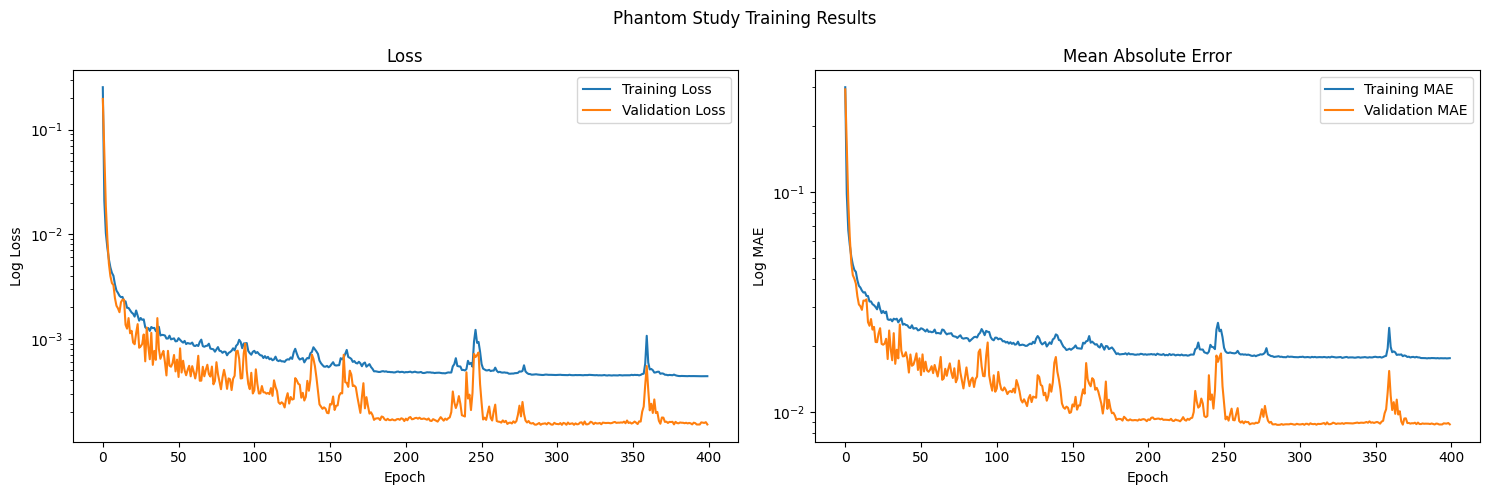

In [5]:
model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name="block_phantom",
    model_dir="D:/DeepSSFP/"
)


deepssfp.plot_training_history(
    history_dict,
    title="Phantom Study Training Results",
    save_path=f"{path}_training_history.png"
)

2025-03-19 11:36:12,289 - DeepSSFP - INFO - Making predictions on data with shape (20, 128, 128, 4)
2025-03-19 11:36:12,734 - DeepSSFP - INFO - Predictions complete. Output shape: (20, 128, 128, 2)
2025-03-19 11:36:16,670 - DeepSSFP - INFO - Prediction visualization saved to D:/DeepSSFP/block_phantom_bandremoval_2_prediction_results.png


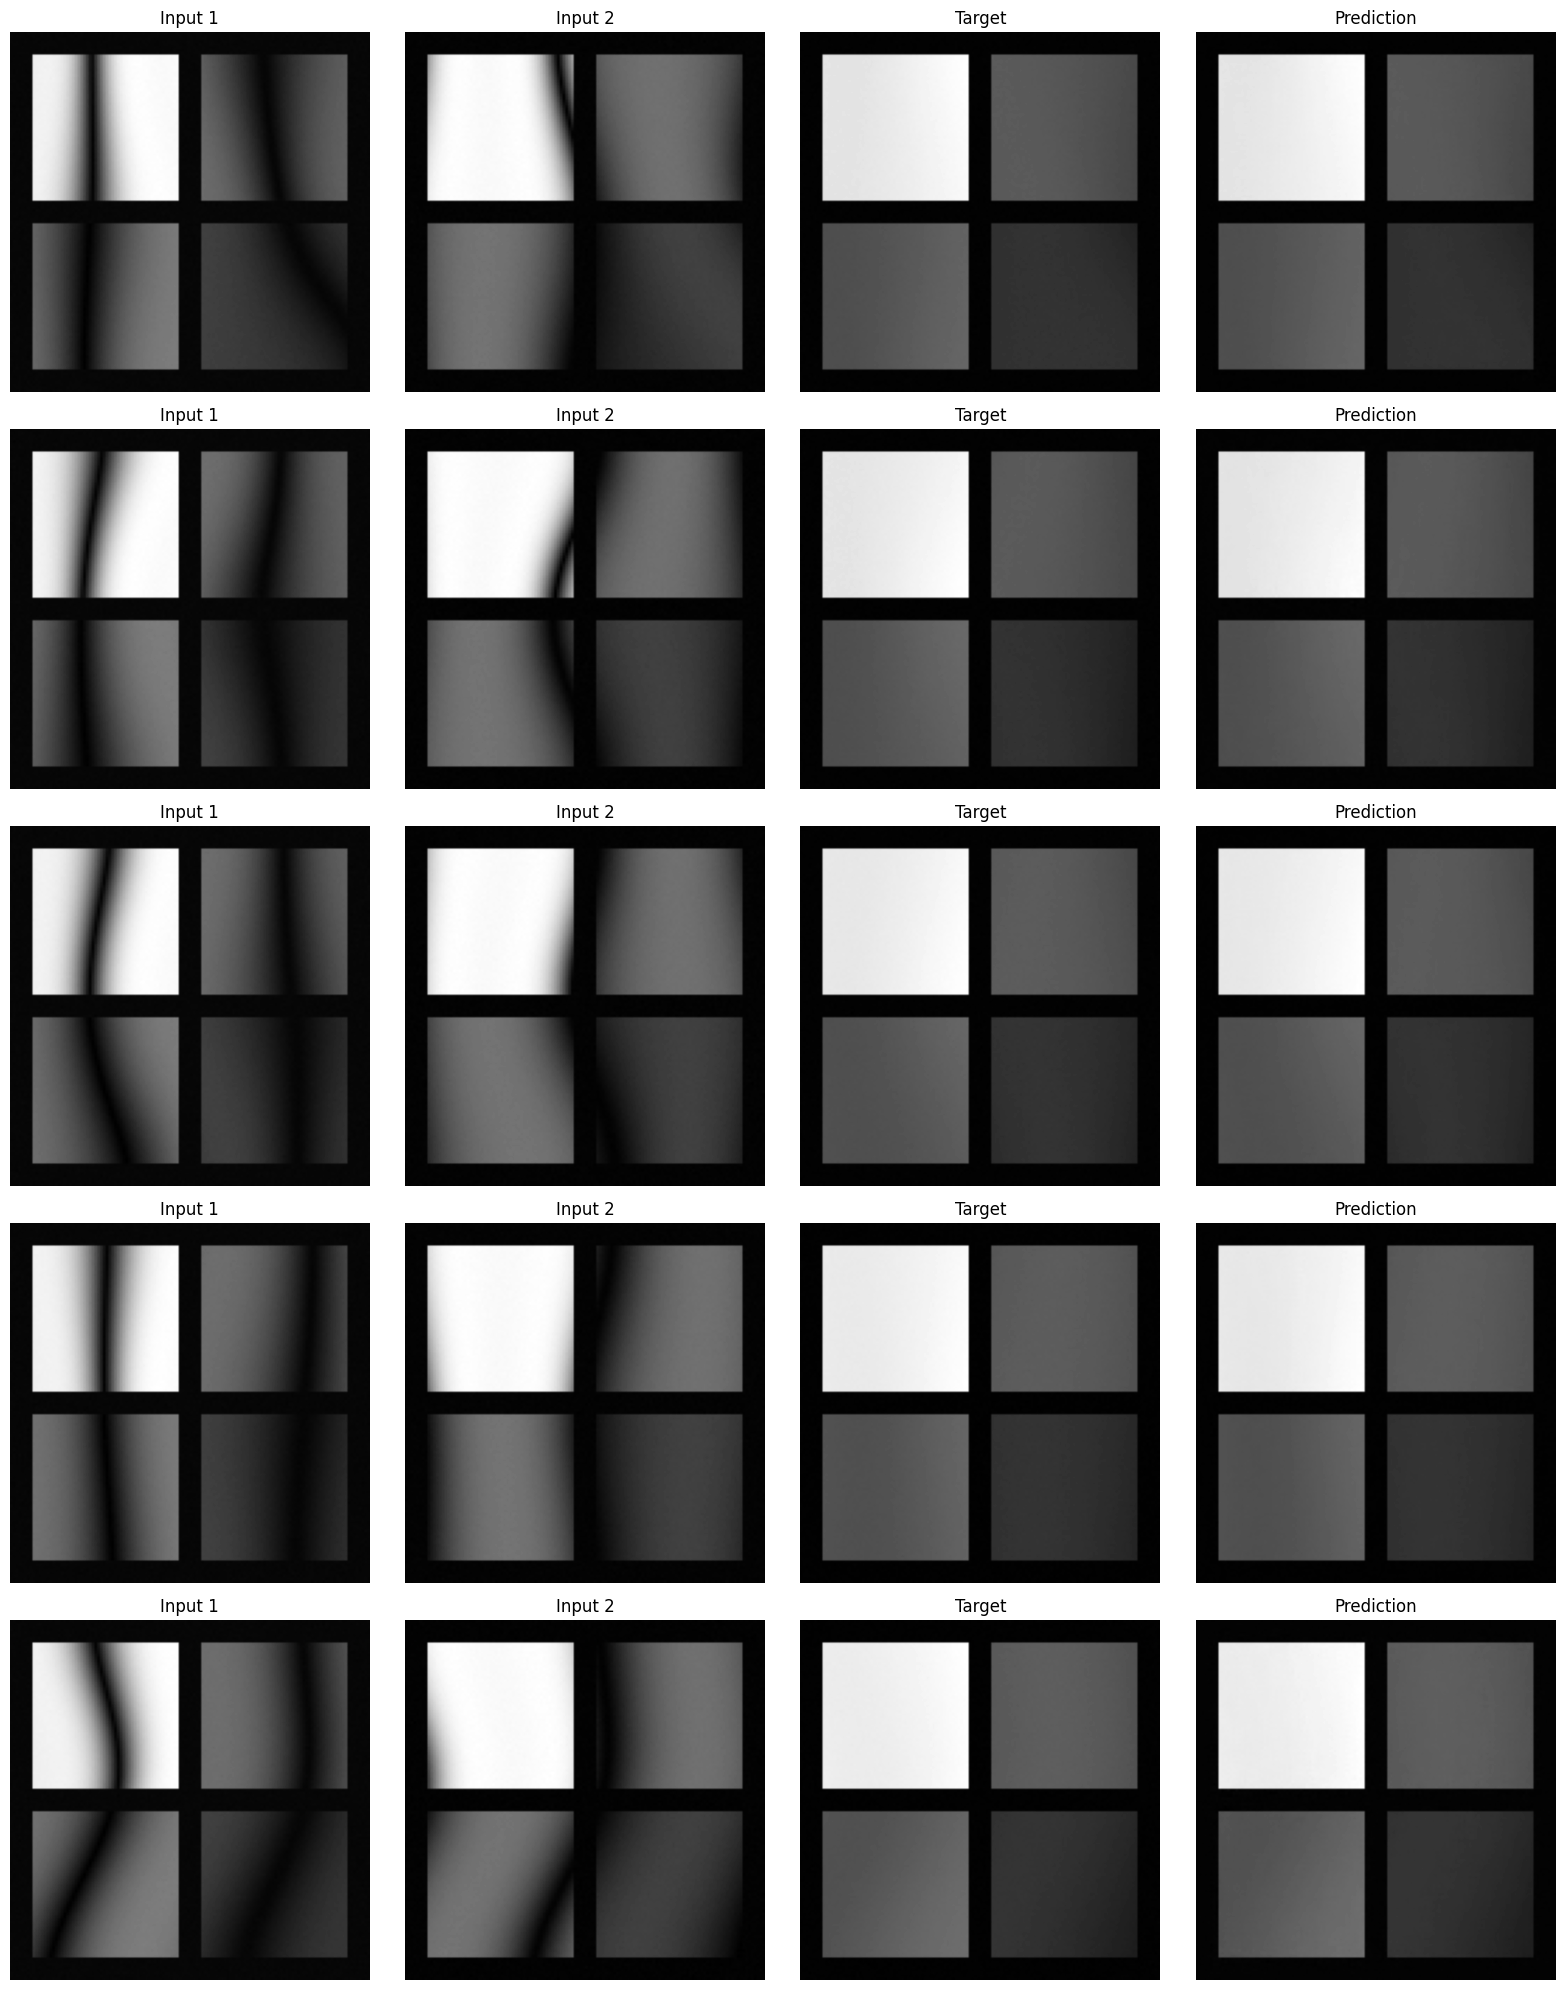

In [6]:
ds = deepssfp.Dataset(mode, input_data=data)

predictions = deepssfp.predict(model, ds.x_test)

deepssfp.visualize_predictions(
    input_images=ds.x_test,
    target_images=ds.y_test,
    predicted_images=predictions,
    num_samples=5,
    save_path=f"{path}_prediction_results.png"
)